# Final Assignment: Walmart Sales

***This is the final assignment of workearly's bootcamp Using Python and Matplotlib. The data are from Walmart and they represent the annual sales of 2012. The goal is to categorize and understand sales performance over time, helping guide future marketing and operational decisions.***

## Import the libraries

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

# import seaborn.objects as so

## Import the dataset

In [2]:
df = pd.read_excel('Filtered_Walmart_Sales_Data.xlsx',sheet_name='Data')
df['Date'] = pd.to_datetime(df['Date'])

In [3]:
df.head()

,ID,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Sales Category,Profit Estimate
0,7170,1,2012-01-06,0,17,8086.43,49.01,3.157,6277.39,21813.16,143.1,1450.13,8483.0,219.714258,7.348,3,151315,Low,808.643
1,7180,1,2012-01-06,0,18,7018.32,49.01,3.157,6277.39,21813.16,143.1,1450.13,8483.0,219.714258,7.348,3,151315,Low,701.832
2,7181,1,2012-01-06,0,19,607.22,49.01,3.157,6277.39,21813.16,143.1,1450.13,8483.0,219.714258,7.348,3,151315,Low,60.722
3,7184,1,2012-01-06,0,12,7634.97,49.01,3.157,6277.39,21813.16,143.1,1450.13,8483.0,219.714258,7.348,3,151315,Low,763.497
4,7192,1,2012-01-06,0,1,16567.69,49.01,3.157,6277.39,21813.16,143.1,1450.13,8483.0,219.714258,7.348,3,151315,Low,1656.769


In [4]:
df = df.rename(columns={'Sales Category':'Sales_Category','Profit Estimate':'Profit_Estimate'})

In [5]:
# columns for making the graphs
sub_df = df[['Date','Weekly_Sales','Dept','Sales_Category','Profit_Estimate']]

## Line Chart: Weekly Sales Over Time

**The below line graph tracks weekly sales across the year 2012, with a shaded area indicating variability (standard deviation).**

In [6]:
sns.set_theme()

In [7]:
# Group data by date and sum the weekly sales to get total sales per week
df_line = df.groupby('Date', as_index=False)['Weekly_Sales'].sum()

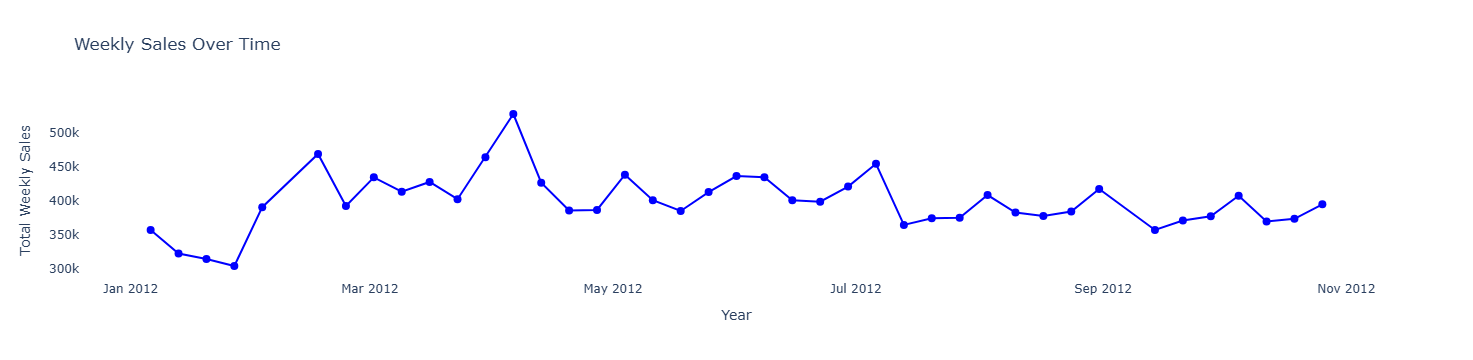

In [13]:
fig1 = go.Figure()

fig1.add_trace(go.Scatter(x=df_line['Date'],
                         y=df_line['Weekly_Sales'],
                         mode='lines+markers', 
                         name='Weekly_Sales',
                         line=dict(color='blue', width=2), 
                         marker=dict(size=8)))

fig1.update_layout(title='Weekly Sales Over Time',
                  xaxis_title='Year',
                  yaxis_title=' Total Weekly Sales',
                  legend=dict(x=0, y=1, bgcolor='rgba(255, 255, 255, 0.5)'),
                  plot_bgcolor='rgba(0, 0, 0, 0)',
                  hovermode='x unified')

fig1.show()

***Insight***:

- Sales peaked around March and June, indicating potential seasonal or promotional boosts.

- Despite fluctuations, the average weekly sales stayed consistent between $20,000 and $30,000.

- The variability suggests different stores or departments may have had uneven performance, which could be explored further.

## Bar Chart: Average Weekly Sales by Category

**This bar chart shows the number of weeks with "High" and "Low" weekly sales**.

In [9]:
av = df["Weekly_Sales"].mean()

In [10]:
fig2 = px.bar(df, x="Sales_Category", y="Weekly_Sales", color='Sales_Category')

fig2.update_layout(
    title="Average Weekly Sales by Category",
    xaxis_title="Sales_Category",
    yaxis_title="Weekly_Sales",
    plot_bgcolor="rgba(0, 0, 0, 0)",
    #hovermode="x unified",
)
fig2.show()

***Insight**: Sales were nearly evenly split, with a slightly higher frequency of "High" sales weeks. This suggests strong performance consistency throughout the year*.

## Histogram: Distribution of Weekly Sales by Category

**This histogram visualizes the distribution of weekly sales amounts, separated by sales category.**

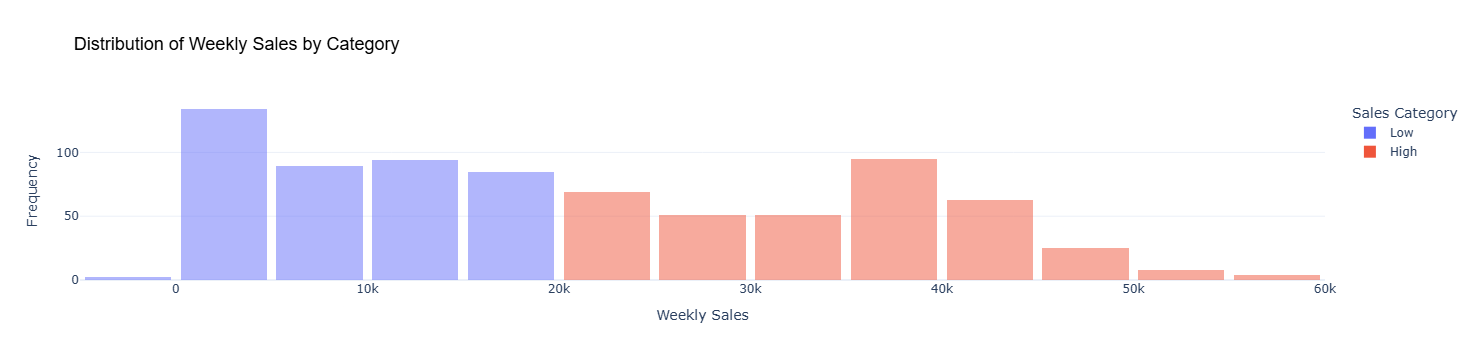

In [11]:
fig3 = px.histogram(
    df,
    x="Weekly_Sales",
    color="Sales_Category",     # Equivalent to hue
    nbins=20,                   # Number of bins
    barmode="stack",            # Stack bars
    opacity=0.5,                # Transparency like alpha
    title="Distribution of Weekly Sales by Category"
)

# Customize axes and title fonts
fig3.update_layout(
    title_font=dict(size=18, family='Arial', color='black'),
    xaxis_title="Weekly Sales",
    yaxis_title="Frequency",
    xaxis_title_font=dict(size=14),
    yaxis_title_font=dict(size=14),
    legend_title="Sales Category",
    template='plotly_white'  # Optional: use a clean white background
)
fig3.update_layout(bargap=0.1)

fig3.show()

***Insight***:

- Weeks with Low sales mostly fall below $20,000.

- High sales are spread between $20,000–$60,000, peaking between $30,000–$40,000.

- There is a clear separation between the two categories, indicating well-defined thresholds.